Experiment

In [ ]:
# 1. Mount Google Drive
import os
from google.colab import drive
drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/5B_ML_Project'
os.chdir(PROJECT_PATH)
print(f"Working directory: {os.getcwd()}")

Mounted at /content/drive
Working directory: /content/drive/.shortcut-targets-by-id/1clF6skobm2Yon4nsTfgjQQ2TU8Aqh2wu/5B_ML_Project


In [ ]:
# 2. Install Dependencies
!pip install pyyaml tqdm -q

In [ ]:
# 3. Check GPU
import torch
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU detected. Enable GPU in Runtime → Change runtime type")

✅ GPU: Tesla T4


In [ ]:
# 4. Load Config
import yaml

with open('config.yaml', 'r') as f:
    config = yaml.safe_load(f)

print("Config loaded")
print(f"   Batch size: {config['batch_size']}")
print(f"   Epochs: {config['epochs']}")
print(f"   Temperature: {config['temperature']}")
print(f"   Alpha: {config['alpha']}")

✅ Config loaded
   Batch size: 128
   Epochs: 30
   Temperature: 4.0
   Alpha: 0.7


In [ ]:
# 5. Run Distillation Experiments

experiments = config['experiments']

# Baseline training for all teachers
# Train baseline ResNet18
!python train.py --mode baseline --student_depth 18 --exp_id baseline_18

# Train baseline ResNet34
!python train.py --mode baseline --student_depth 34 --exp_id baseline_34

# Train baseline ResNet50
!python train.py --mode baseline --student_depth 50 --exp_id baseline_50

# Train baseline ResNet101
!python train.py --mode baseline --student_depth 101 --exp_id baseline_101

# Train baseline ResNet152
!python train.py --mode baseline --student_depth 152 --exp_id baseline_152

for exp in experiments:
    print(f"\n{'='*60}")
    print(f"{exp['description']}")
    print(f"   Teacher: ResNet{exp['teacher_depth']} (ImageNet pretrained)")
    print(f"   Student: ResNet{exp['student_depth']}")
    print(f"   Capacity Ratio: {exp.get('ratio', 'N/A')}")
    print(f"{'='*60}")

    teacher_checkpoint = f"{PROJECT_PATH}/checkpoints/baseline_{exp['teacher_depth']}/best.pth"

    # Run distillation
    !python train.py \
        --mode distill \
        --teacher_depth {exp['teacher_depth']} \
        --student_depth {exp['student_depth']} \
        --exp_id {exp['id']} \
        --teacher_checkpoint {teacher_checkpoint}

    print(f"Completed {exp['id']}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 124MB/s]

Mode: BASELINE
Student: ResNet18 (11,173,962 params)
/content/drive/.shortcut-targets-by-id/1clF6skobm2Yon4nsTfgjQQ2TU8Aqh2wu/5B_ML_Project/train.py:121: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None
✅ Loaded checkpoint from checkpoints/baseline_18/best.pth (epoch 50, accuracy 88.92%)
🔄 Found exi

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 6. Collect Results
import yaml
import pandas as pd
import glob
import os

results = []
for exp in experiments:
    result_path = f"results/{exp['id']}.yaml"
    if os.path.exists(result_path):
        with open(result_path, 'r') as f:
            data = yaml.safe_load(f)
            results.append({
                'Experiment': exp['id'],
                'Teacher': f"ResNet{data['teacher_depth']}",
                'Student': f"ResNet{data['student_depth']}",
                'Ratio': f"{data['ratio']:.2f}",
                'Best Acc (%)': f"{data['best_accuracy']:.2f}"
            })

df = pd.DataFrame(results)
print("\n" + "="*70)
print("EXPERIMENT SUMMARY")
print("="*70)
print(df.to_string(index=False))

# Save to Drive
df.to_csv(f"{PROJECT_PATH}/results/summary.csv", index=False)
print(f"\nSummary saved to {PROJECT_PATH}/results/summary.csv")


EXPERIMENT SUMMARY
   Experiment   Teacher  Student Ratio Best Acc (%)
      same_18  ResNet18 ResNet18  1.00        90.09
      same_34  ResNet34 ResNet34  1.00        91.26
  small_34_18  ResNet34 ResNet18  1.90        86.36
 medium_50_18  ResNet50 ResNet18  2.10        88.26
 large_101_18 ResNet101 ResNet18  3.80        88.52
xlarge_152_18 ResNet152 ResNet18  5.20        83.85

✅ Summary saved to /content/drive/MyDrive/5B_ML_Project/results/summary.csv


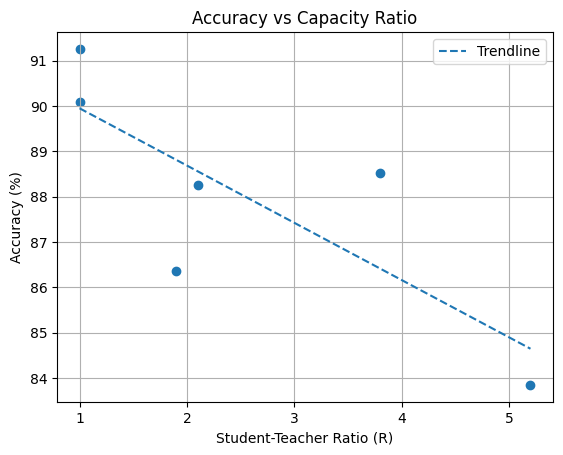

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Data
capacity_ratio = [1.0, 1.0, 1.9, 2.1, 3.8, 5.2]
accuracy = [90.09, 91.26, 86.36, 88.26, 88.52, 83.85]

# Convert to numpy arrays
x = np.array(capacity_ratio)
y = np.array(accuracy)

# Create plot
plt.figure()

# Original line + scatter
plt.scatter(x, y)

coeffs = np.polyfit(x, y, 1)          # degree 1 = linear
trendline = np.poly1d(coeffs)

# Smooth x for nicer line
x_smooth = np.linspace(min(x), max(x), 100)

plt.plot(x_smooth, trendline(x_smooth), linestyle='--', label='Trendline')

# Labels and title
plt.xlabel("Student-Teacher Ratio (R)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Capacity Ratio")

plt.legend()
plt.grid(True)

plt.show()